## **CLUSTERIZACIÓN DE SLOPE UNITS**

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from typing import List, Dict, Optional

In [2]:
path_su = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final_mm.gpkg"
gdf = gpd.read_file(path_su)

gdf.head()

,Id,gridcode,Shape_Leng,Shape_Area,slope_mean,curva_mean,acos_mean,asin_mean,aspect_mea,area,...,cobertura_cat,cobertura,n_mm,si_no,suelos,zona_lluvia,curva_std_mean,curva_std_std,cluster_prob,geometry
0,3683,2978,724.443245,23009.556086,23.656450,0.003081,0.853198,0.206826,13.626339,0.003555,...,2.0,Territorios agrícolas,0,0,Areno-arcilloso,2.0,2.040103,4.435678,0.849750,"MULTIPOLYGON (((862736.779 1211959.991, 862736..."
1,4178,3888,441.842741,10463.388311,20.119491,-0.002061,-0.548672,0.750604,126.165838,0.010458,...,2.0,Territorios agrícolas,0,0,Areno-arcilloso,2.0,0.298016,3.704263,0.523830,"MULTIPOLYGON (((862916.264 1211961.269, 862917..."
2,4666,4314,478.805068,9837.858532,22.920414,-0.001765,-0.640250,0.614889,136.157556,0.002859,...,2.0,Territorios agrícolas,0,0,Areno-arcilloso,2.0,-0.626527,3.649850,0.395114,"MULTIPOLYGON (((862731.079 1211900.499, 862734..."
3,4669,4315,602.184217,13182.718538,20.990250,0.000634,0.327328,0.770644,66.986857,0.008595,...,2.0,Territorios agrícolas,0,0,Areno-arcilloso,2.0,0.767061,3.532290,0.644216,"MULTIPOLYGON (((862934.093 1211984.615, 862934..."
4,5221,5115,533.482334,7543.447490,14.661900,-0.001002,0.515300,0.664819,52.220823,0.003925,...,2.0,Territorios agrícolas,0,0,Areno-arcilloso,2.0,-0.371482,3.576741,0.944913,"MULTIPOLYGON (((862720.787 1211859.908, 862720..."


In [3]:
def preparar_variables_cluster(
    gdf: gpd.GeoDataFrame,
    variables: List[str],
    slope_col: str = "slope_mean",
    aspect_col: str = "aspect_mea",
    curva_col: str = "curva_mean"
):
    """
    Prepara la matriz X para clusterización.
    El aspecto se descompone en (sin, cos) para respetar su naturaleza circular.
    """
    variables_validas = {"slope", "aspect", "curva"}
    variables = list(dict.fromkeys(variables))

    invalidas = [v for v in variables if v not in variables_validas]
    if invalidas:
        raise ValueError(f"Variables no válidas: {invalidas}. Usa solo: {sorted(variables_validas)}")
    if len(variables) == 0:
        raise ValueError("Debes elegir al menos una variable.")

    col_map = {"slope": slope_col, "aspect": aspect_col, "curva": curva_col}
    cols_necesarias = [col_map[v] for v in variables] + ["geometry"]
    faltantes = [c for c in cols_necesarias if c not in gdf.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas requeridas: {faltantes}")

    gdf2 = gdf.copy()
    for v in variables:
        gdf2[col_map[v]] = pd.to_numeric(gdf2[col_map[v]], errors="coerce")
    gdf2 = gdf2.dropna(subset=[col_map[v] for v in variables]).copy()

    features = {}
    if "slope" in variables:
        features["slope_mean"] = gdf2[slope_col].to_numpy()
    if "curva" in variables:
        features["curva_std_mean"] = gdf2[curva_col].to_numpy()
    if "aspect" in variables:
        theta = np.deg2rad(gdf2[aspect_col].to_numpy())
        features["aspect_sin"] = np.sin(theta)
        features["aspect_cos"] = np.cos(theta)

    X = pd.DataFrame(features, index=gdf2.index)
    feature_names = X.columns.tolist()
    return gdf2, X, feature_names


def escalar_y_ponderar(
    X: pd.DataFrame,
    pesos: Optional[Dict[str, float]] = None
):
    """
    Estandariza X con StandardScaler y aplica pesos por columna
    DESPUÉS del escalado.

    Por defecto, si existen las columnas aspect_sin y aspect_cos,
    se les aplica un peso de 1/sqrt(2) para que el aspecto (que aporta
    2 columnas) tenga un peso efectivo equivalente a una sola variable,
    igualándolo a slope y curva.

    Parámetros
    ----------
    X : DataFrame con las features sin escalar.
    pesos : dict opcional. Si se pasa, sobreescribe los pesos por defecto.
            Ejemplo: {"slope_mean": 1.0, "curva_mean": 1.0,
                      "aspect_sin": 1/np.sqrt(2), "aspect_cos": 1/np.sqrt(2)}

    Retorna
    -------
    X_scaled : ndarray listo para clusterizar.
    pesos_aplicados : dict con los pesos usados (para trazabilidad).
    scaler : el StandardScaler ajustado.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

    # Pesos por defecto: balancear aspecto
    if pesos is None:
        pesos = {col: 1.0 for col in X.columns}
        if "aspect_sin" in X.columns and "aspect_cos" in X.columns:
            w_aspect = 1.0 / np.sqrt(2)
            pesos["aspect_sin"] = w_aspect
            pesos["aspect_cos"] = w_aspect

    # Aplicar pesos columna por columna
    for col, w in pesos.items():
        if col in X_scaled_df.columns:
            X_scaled_df[col] = X_scaled_df[col] * w

    return X_scaled_df.to_numpy(), pesos, scaler


In [4]:

# ---------------- FLUJO PRINCIPAL ----------------

gdf_clust, X, feature_names = preparar_variables_cluster(
    gdf,
    variables=["curva", "slope"]
)

#["curva", "aspect", "slope"]
X_scaled, pesos_aplicados, scaler = escalar_y_ponderar(X)

print("Variables usadas:", feature_names)
print("Pesos aplicados tras el escalado:")
for col, w in pesos_aplicados.items():
    print(f"  {col:15s} -> {w:.4f}")

Variables usadas: ['slope_mean', 'curva_std_mean']
Pesos aplicados tras el escalado:
  slope_mean      -> 1.0000
  curva_std_mean  -> 1.0000


In [5]:
print("\nVarianza aportada por cada grupo de variables (tras ponderación):")
var_por_columna = X_scaled.var(axis=0)
for col, v in zip(feature_names, var_por_columna):
    print(f"  {col:15s} -> var = {v:.4f}")
#print(f"  Varianza total del aspecto (sin+cos): {var_por_columna[feature_names.index('aspect_sin')] + var_por_columna[feature_names.index('aspect_cos')]:.4f}")
print(f"  Varianza slope: {var_por_columna[feature_names.index('slope_mean')]:.4f}")
print(f"  Varianza curva: {var_por_columna[feature_names.index('curva_std_mean')]:.4f}")


Varianza aportada por cada grupo de variables (tras ponderación):
  slope_mean      -> var = 1.0000
  curva_std_mean  -> var = 1.0000
  Varianza slope: 1.0000
  Varianza curva: 1.0000


In [6]:
def evaluar_gmm_k(
    X_scaled: np.ndarray,
    k_values=range(2, 9),
    covariance_type: str = "full",
    random_state: int = 42
) -> pd.DataFrame:
    """
    Ajusta un GMM para varios valores de k y calcula métricas de evaluación.
    """
    resultados = []

    for k in k_values:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=random_state,
            reg_covar=1e-6,
            n_init=10
        )
        labels = gmm.fit_predict(X_scaled)

        resultados.append({
            "k": k,
            "bic": gmm.bic(X_scaled),
            "aic": gmm.aic(X_scaled),
            "silhouette": silhouette_score(X_scaled, labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels)
        })

    return pd.DataFrame(resultados)


df_eval = evaluar_gmm_k(X_scaled, k_values=range(2, 9))
print(feature_names)
print(df_eval)

['slope_mean', 'curva_std_mean']
   k            bic            aic  silhouette  calinski_harabasz  \
0  2  321892.940345  321793.691871    0.351147        9307.098471   
1  3  318098.833257  317945.449253    0.400048       26915.618054   
2  4  316583.927776  316376.408241    0.359965       20386.764910   
3  5  315793.037222  315531.382155    0.330178       19588.167527   
4  6  315193.789140  314877.998543    0.325813       17619.302233   
5  7  314783.437093  314413.510964    0.291212       19303.476942   
6  8  314335.747990  313911.686330    0.307499       20454.981104   

   davies_bouldin  
0        2.010035  
1        1.202761  
2        1.733751  
3        1.957058  
4        2.721808  
5        1.388630  
6        1.380274  


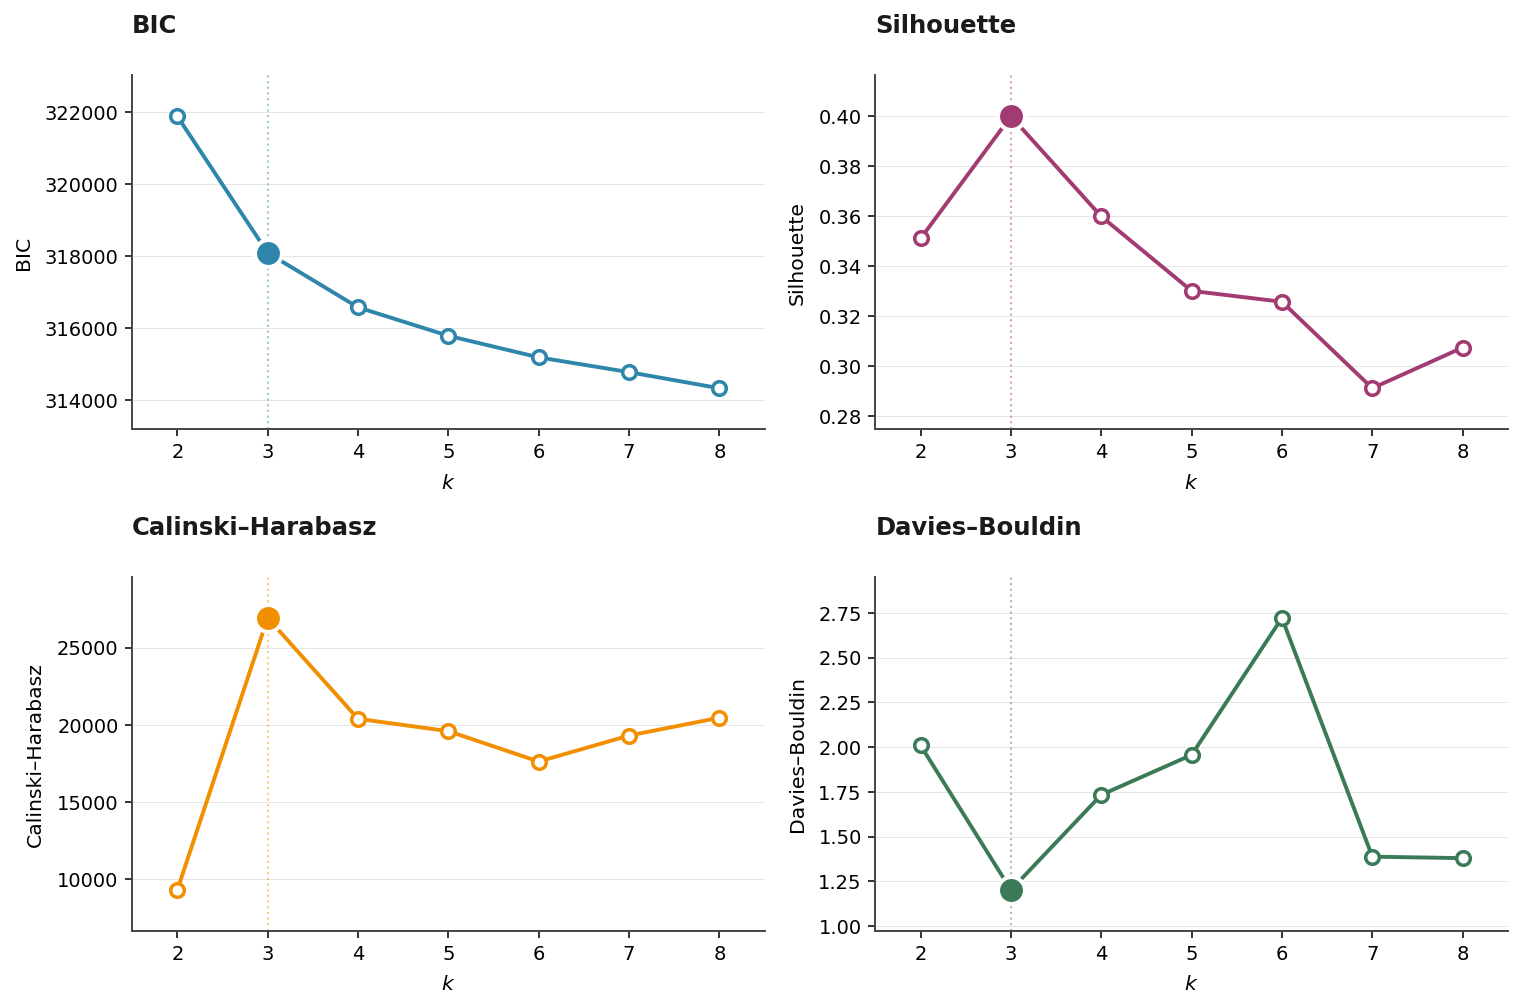

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ------------------------------------------------------------
# Detector de codo (segunda diferencia discreta)
# ------------------------------------------------------------
def find_elbow(y):
    """
    Detecta el codo en una curva como el punto de máxima curvatura
    discreta, usando la segunda diferencia:
        d2[i] = y[i-1] - 2*y[i] + y[i+1]
    Es el análogo discreto a la segunda derivada y captura el k
    donde cambia más bruscamente la pendiente (el "quiebre" visual).
    """
    y = np.asarray(y, dtype=float)
    if len(y) < 3:
        return 0
    d2 = y[:-2] - 2 * y[1:-1] + y[2:]
    return int(np.argmax(np.abs(d2))) + 1   # +1 porque d2 omite extremos

# ------------------------------------------------------------
# Estilo global
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    12.5,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    1.0,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.frameon":    False,
})

# ------------------------------------------------------------
# Configuración por panel
# ------------------------------------------------------------
panels = [
    {"key": "bic",               "title": "BIC",
     "color": "#2E86AB", "best": "elbow"},   # ← codo
    {"key": "silhouette",        "title": "Silhouette",
     "color": "#A23B72", "best": "max"},
    {"key": "calinski_harabasz", "title": "Calinski–Harabasz",
     "color": "#F18F01", "best": "max"},
    {"key": "davies_bouldin",    "title": "Davies–Bouldin",
     "color": "#3B7A57", "best": "min"},
]

# ------------------------------------------------------------
# Figura
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 7.8), dpi=140)
axes = axes.flatten()

k_vals = df_eval["k"].to_numpy()

for ax, p in zip(axes, panels):
    y = df_eval[p["key"]].to_numpy()
    color = p["color"]

    # Selección del k óptimo según criterio
    if p["best"] == "min":
        idx_opt = int(np.argmin(y))
    elif p["best"] == "max":
        idx_opt = int(np.argmax(y))
    elif p["best"] == "elbow":
        idx_opt = find_elbow(y)
    else:
        raise ValueError(f"best='{p['best']}' no reconocido")

    k_opt, y_opt = k_vals[idx_opt], y[idx_opt]

    # Línea principal con marcadores huecos
    ax.plot(
        k_vals, y,
        color=color, linewidth=2.0,
        marker="o", markersize=7,
        markerfacecolor="white", markeredgewidth=1.8,
        markeredgecolor=color,
        zorder=3,
    )

    # Línea vertical guía en el óptimo
    ax.axvline(k_opt, color=color, linestyle=":", linewidth=1.1,
               alpha=0.45, zorder=1)

    # Marcador del óptimo (relleno)
    ax.scatter([k_opt], [y_opt], s=190,
               color=color, edgecolor="white", linewidth=2.0, zorder=5)

    # Títulos y ejes
    ax.set_title(p["title"], pad=22, loc="left", color="#1a1a1a")
    ax.set_xlabel("$k$", labelpad=6)
    ax.set_ylabel(p["title"], labelpad=6)

    # Grilla y ejes
    ax.grid(True, axis="y", linestyle="-", linewidth=0.5,
            color="#E5E5E5", zorder=0)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(k_vals.min() - 0.5, k_vals.max() + 0.5)

    y_range = y.max() - y.min()
    ax.set_ylim(y.min() - 0.15 * y_range, y.max() + 0.15 * y_range)

    for s in ["left", "bottom"]:
        ax.spines[s].set_color("#444444")

plt.tight_layout(rect=[0, 0.02, 1, 0.96])

#plt.savefig("metricas_seleccion_k.png", bbox_inches="tight", facecolor="white", dpi=100)
plt.show()

In [8]:
k_final = 3

gmm_final = GaussianMixture(
    n_components=k_final,
    covariance_type="full",
    random_state=42,
    reg_covar=1e-6,
    n_init=10                        # ← agregar
)

labels_final = gmm_final.fit_predict(X_scaled)
probs_final = gmm_final.predict_proba(X_scaled)

gdf_clust["su_type"] = labels_final + 1
gdf_clust["cluster_prob"] = probs_final.max(axis=1)

In [9]:
resumen = (
    gdf_clust
    .groupby("su_type")[["slope_mean", "curva_mean", "aspect_mea"]]
    .agg(["mean", "median", "std", "count"])
)

print(resumen)

        slope_mean                             curva_mean                      \
              mean     median       std  count       mean    median       std   
su_type                                                                         
1        30.309135  29.686455  4.898482  31636   0.000100  0.000112  0.000880   
2        16.804295  16.878031  3.696511  23012  -0.000149 -0.000098  0.000727   
3        27.674450  27.330474  8.445360   6594  -0.002710 -0.002820  0.002941   

                aspect_mea                                 
         count        mean      median         std  count  
su_type                                                    
1        31636  185.738839  190.194712  104.318577  31636  
2        23012  179.267839  175.437666   99.376864  23012  
3         6594  181.931580  187.180406  106.784221   6594  


In [10]:
tabla_n = gdf_clust["su_type"].value_counts().sort_index()
tabla_pct = 100 * tabla_n / len(gdf_clust)

tabla_clusters = pd.DataFrame({
    "n": tabla_n,
    "pct": tabla_pct
})

print(tabla_clusters)

             n        pct
su_type                  
1        31636  51.657359
2        23012  37.575520
3         6594  10.767121


In [11]:
# path_out = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_clusterizadas_todos.gpkg"
# gdf_clust.to_file(path_out, driver="GPKG")

path_out = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final_mm.gpkg"
gdf_clust.to_file(path_out, driver="GPKG")

In [12]:
def caracterizar_clusters(
    gdf_clust: gpd.GeoDataFrame,
    gmm: GaussianMixture,
    scaler: StandardScaler,
    feature_names: list,
    cluster_col: str = "su_type"
) -> dict:
    """
    Caracteriza los clusters GMM en el espacio original de variables.

    Retorna
    -------
    dict con:
        - centroides_modelo: medias del GMM en unidades originales
        - resumen_empirico: stats por cluster (mean, median, std, q25, q75)
        - dispersion_modelo: desviaciones del modelo (sqrt de la diagonal de cov)
        - tabla_n: tamaño y porcentaje de cada cluster
    """
    # 1) Centroides del modelo (en unidades originales)
    centroides_orig = scaler.inverse_transform(gmm.means_)
    df_centroides = pd.DataFrame(
        centroides_orig,
        columns=feature_names,
        index=[f"SU {i+1}" for i in range(gmm.n_components)]
    )

    # 2) Desviaciones por cluster (raíz de la diagonal de la covarianza)
    #    Reescaladas al espacio original
    sigmas_orig = []
    for k in range(gmm.n_components):
        cov_k = gmm.covariances_[k]                  # en espacio escalado
        var_orig = np.diag(cov_k) * (scaler.scale_ ** 2)  # ajuste por escala
        sigmas_orig.append(np.sqrt(var_orig))
    df_sigmas = pd.DataFrame(
        sigmas_orig,
        columns=[f"sd_{c}" for c in feature_names],
        index=[f"SU {i+1}" for i in range(gmm.n_components)]
    )

    # 3) Resumen empírico (de los datos, no del modelo)
    vars_originales = ["slope_mean", "curva_mean"]
    resumen = (
        gdf_clust
        .groupby(cluster_col)[vars_originales]
        .agg(["mean", "median", "std",
              lambda x: x.quantile(0.25),
              lambda x: x.quantile(0.75),
              "count"])
    )
    # Renombrar percentiles
    resumen.columns = [
        f"{var}_{stat}" if stat not in ("<lambda_0>", "<lambda_1>")
        else f"{var}_{'q25' if stat=='<lambda_0>' else 'q75'}"
        for var, stat in resumen.columns
    ]

    # 4) Tabla de tamaños
    tabla_n = gdf_clust[cluster_col].value_counts().sort_index()
    tabla_pct = (100 * tabla_n / len(gdf_clust)).round(2)
    tabla_size = pd.DataFrame({"n": tabla_n, "pct": tabla_pct})

    return {
        "centroides_modelo": df_centroides,
        "dispersion_modelo": df_sigmas,
        "resumen_empirico": resumen,
        "tabla_n": tabla_size
    }


# --- Uso ---
carac = caracterizar_clusters(
    gdf_clust=gdf_clust,
    gmm=gmm_final,
    scaler=scaler,
    feature_names=feature_names,
    cluster_col="su_type"
)

print("=== CENTROIDES (medias del modelo, unidades originales) ===")
print(carac["centroides_modelo"].round(5))
print("\n=== DISPERSIÓN POR CLUSTER (sd del modelo) ===")
print(carac["dispersion_modelo"].round(5))
print("\n=== RESUMEN EMPÍRICO POR CLUSTER ===")
print(carac["resumen_empirico"].round(5))
print("\n=== TAMAÑO DE CLUSTERS ===")
print(carac["tabla_n"])

=== CENTROIDES (medias del modelo, unidades originales) ===
      slope_mean  curva_std_mean
SU 1    29.91820         0.00008
SU 2    17.36844        -0.00014
SU 3    27.56106        -0.00178

=== DISPERSIÓN POR CLUSTER (sd del modelo) ===
      sd_slope_mean  sd_curva_std_mean
SU 1        5.42025            0.00091
SU 2        4.43298            0.00074
SU 3        8.23651            0.00279

=== RESUMEN EMPÍRICO POR CLUSTER ===
         slope_mean_mean  slope_mean_median  slope_mean_std  slope_mean_q25  \
su_type                                                                       
1               30.30913           29.68645         4.89848        26.42295   
2               16.80430           16.87803         3.69651        13.72977   
3               27.67445           27.33047         8.44536        21.47297   

         slope_mean_q75  slope_mean_count  curva_mean_mean  curva_mean_median  \
su_type                                                                         
1       

In [13]:
carac["centroides_modelo"]

,slope_mean,curva_std_mean
SU 1,29.918203,0.000077
SU 2,17.368435,-0.000140
SU 3,27.561065,-0.001775


In [14]:
def nombrar_tipologias(centroides: pd.DataFrame) -> dict:
    """
    Asigna nombres descriptivos a los clusters basándose en pendiente y curvatura.
    Sigue convenciones geomorfológicas (Pike 1988, Tarboton).
    """
    nombres = {}
    for idx, row in centroides.iterrows():
        slope = row["slope_mean"]
        curva = row["curva_std_mean"]

        # Categoría por pendiente
        if slope < 12:
            cat_slope = "suaves"
        elif slope < 25:
            cat_slope = "intermedias"
        else:
            cat_slope = "empinadas"

        # Categoría por curvatura (ajusta el umbral según rangos de tus datos)
        if curva > 0.0005:
            cat_curva = "convexas"
        elif curva < -0.0005:
            cat_curva = "cóncavas"
        else:
            cat_curva = "cóncavo-convexas"

        nombres[idx] = f"Laderas {cat_slope} {cat_curva}"

    return nombres


nombres_su = nombrar_tipologias(carac["centroides_modelo"])
for su, nombre in nombres_su.items():
    print(f"{su} -> {nombre}")

SU 1 -> Laderas empinadas cóncavo-convexas
SU 2 -> Laderas intermedias cóncavo-convexas
SU 3 -> Laderas empinadas cóncavas


In [15]:
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample

def validar_estabilidad_gmm(
    X_scaled: np.ndarray,
    labels_ref: np.ndarray,
    k: int = 3,
    n_bootstrap: int = 30,
    sample_frac: float = 0.8,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Evalúa la estabilidad de la partición GMM con remuestreo.
    Reajusta el GMM en sub-muestras del 80% y mide el ARI entre
    la predicción sobre TODOS los puntos y las etiquetas de referencia.

    ARI = 1   -> partición idéntica
    ARI > 0.8 -> partición muy estable
    ARI ~ 0   -> partición aleatoria
    """
    rng = np.random.RandomState(random_state)
    aris = []

    for b in range(n_bootstrap):
        idx_sub = resample(
            np.arange(len(X_scaled)),
            n_samples=int(sample_frac * len(X_scaled)),
            replace=False,
            random_state=rng.randint(0, 1_000_000)
        )

        gmm_b = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=rng.randint(0, 1_000_000),
            reg_covar=1e-6
        ).fit(X_scaled[idx_sub])

        labels_b = gmm_b.predict(X_scaled)  # predigo sobre TODOS los puntos
        ari = adjusted_rand_score(labels_ref, labels_b)
        aris.append({"iter": b, "ari": ari})

    return pd.DataFrame(aris)


df_estab = validar_estabilidad_gmm(
    X_scaled=X_scaled,
    labels_ref=labels_final,
    k=3,
    n_bootstrap=30
)

print(f"ARI medio:   {df_estab['ari'].mean():.3f}")
print(f"ARI mediano: {df_estab['ari'].median():.3f}")
print(f"ARI mínimo:  {df_estab['ari'].min():.3f}")
print(f"ARI p25-p75: {df_estab['ari'].quantile(0.25):.3f} – {df_estab['ari'].quantile(0.75):.3f}")

ARI medio:   0.990
ARI mediano: 0.991
ARI mínimo:  0.983
ARI p25-p75: 0.986 – 0.993


In [16]:
# Cruzar tipos de SU con inventario de movimientos en masa
# Asumiendo que tienes la columna n_eventos o un flag de presencia

stats_eventos = (
    gdf_clust
    .groupby("su_type")
    .agg(
        n_su=("su_type", "size"),
        area_total_km2=("geometry", lambda g: g.area.sum() / 1e6),
        n_eventos=("n_mm", "sum"),   # ajusta el nombre real
        su_con_evento=("n_mm", lambda x: (x > 0).sum())
    )
)
stats_eventos["densidad_eventos_km2"] = (
    stats_eventos["n_eventos"] / stats_eventos["area_total_km2"]
)
stats_eventos["prob_evento_su"] = (
    stats_eventos["su_con_evento"] / stats_eventos["n_su"]
)
print(stats_eventos)

          n_su  area_total_km2  n_eventos  su_con_evento  \
su_type                                                    
1        31636      575.558140       4668           2935   
2        23012      383.843534       1209            874   
3         6594       47.575657        321            251   

         densidad_eventos_km2  prob_evento_su  
su_type                                        
1                    8.110388        0.092774  
2                    3.149721        0.037980  
3                    6.747148        0.038065  
